# Evaluación Parcial N.º 1: Preparación y análisis exploratorio de datos


# Indice según rúbrica:  
&rarr; Cada punto tiene sub-índices. Esto solo lleva a los headers principales.  
[3.1 Fuentes de datos y herramientas colaborativas. (10%)](#section-31)  
[3.2 Manipulación y preparación de datos en Python (30%)](#section-32)  
[3.3. Análisis exploratorio y calidad de los datos (40%)](#section-33)  
[3.4. Sesgos, ética y privacidad (20%)](#section-34)  

# 0. Identificación y declaración de uso de IA

- **Nombre completo:** Marvin Rafael Francisconi Camacho
- **Caso asignado:** C
- **Nombre del archivo de datos utilizado:** *Spotify_Tracks_Dataset.csv*
- **Uso de IA:** Para mostrar datos en la sección [3.3.3](#section-333), ChatGPT fue utilizado para saber que herramienta se puede utilizar. (Display)

# 1. Dataset asignado

 Caso C — [Spotify_Dataset.zip](https://drive.google.com/file/d/1FLrhfZ4WGxWyBvUaY8hjdGrN-mcgZsdb/view?usp=sharing)



# 2. Disclaimer sobre rúbrica e instrucciones.

Todo se responderá a partir de la rúbrica evaluativa.  
El resto de *"correcciones complementarias"* se seguirán como quedó en la instrucción.

### *Imports.*

**Nota** | Python 3.14.7  
&rarr; Actualizar de ser necesario.

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
from scipy.stats import zscore
from IPython.display import display # ChatGPT me dijo como mostrar los datos de la 3.3.3 con este import.

---

# 3. Aplicación de rúbrica para resolver la evaluación.

<a id="section-31"></a>  

## 3.1 Fuentes de datos y herramientas colaborativas. (10%)

Según la rúbrica para alcanzar el 10% se debe:  

* Identificar correctamente la fuente, unidad de observación, variable objetivo y variables relevantes. Incluye un diccionario breve y explica el uso de una herramienta para organizar, respaldar o documentar el trabajo. La información coincide entre notebook y presentación.  


#### &rarr; Sobra decir que se debe revisar el archivo y la presentación para tomar nota de que, en efecto, la información "*coincide*" entre notebook y presentación. &larr;

### 3.1.1 Identificar la fuente:

* Fuente: dataset Spotify Tracks asignado para el Caso C. El conjunto contiene información descriptiva y características acústicas de canciones, incluyendo popularidad, género y atributos musicales.

### 3.1.2 Identificar una unidad de observación:
*  Cómo unidad de observación, se utilizará la unidad *canción*, es decir, cada fila (objeto) será una *canción*.

### 3.1.3 Indetificar variable objetivo:
* Como variable objetivo se utilizará la palabra clave *popularidad* que tiene medidas escalares de 0 a 100.

### 3.1.4 y 3.1.5 Identificar variables relevantes y diccionario breve:
| Grupo                     | Variables                                                                                                      | Traducción / descripción                                                                                                           |
| ------------------------- | -------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| Identificación            | track_id                                                                                                     | Identificador de la canción                                                                                                        |
| Información de canción    | artists, album_name, track_name                                                                         | Artista(s), nombre del álbum y nombre de la canción                                                                                |
| Variable objetivo         | popularity                                                                                                   | Popularidad de la canción, en escala de 0 a 100                                                                                    |
| Duración                  | duration_ms                                                                                                  | Duración de la canción en milisegundos                                                                                             |
| Contenido                 | explicit                                                                                                     | Indica si la canción contiene contenido explícito                                                                                  |
| Características musicales | danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence | Bailabilidad, energía, volumen, presencia de voz hablada, acústica, instrumentalidad, interpretación en vivo y positividad musical |
| Estructura musical        | key, mode, tempo, time_signature                                                                       | Tonalidad, modalidad, tempo y compás musical                                                                                       |
| Clasificación             | track_genre                                                                                                 | Género musical de la canción                                                                                                       |


### 3.1.6 Herrameinta para organizar, respaldar y documentar el trabajo.
* Se utilizará un repositorio Github público. Haz click &rarr; [aquí](https://github.com/francisconimarvin/MLY1101_001V_EV1_CC_MarvinFrancisconi) &larr; para acceder.

---

<a id="section-32"></a>  

## 3.2 Manipulación y preparación de datos en Python (30%)  
Según la rúbrica, para alcanzar un buen desempeño y obtener el 30% total se debe cumplir con lo siguiente:

El notebook carga los datos de forma reproducible, corrige los problemas relevantes y deja un dataset final utilizable. Cada transformación importante incluye evidencia, acción y justificación. Se distinguen claramente los datos originales de los preparados y el notebook se ejecuta completamente sin errores.

### 3.2.1 Carga reproducible de los datos.
### 3.2.2 Se crea una copia del DataFrame original para prepararlos, dejando el original sin alterar.

In [90]:
# Se utiliza relative path, se espera que todo esté dentro de un mismo directorio.
df = pd.read_csv("Spotify_Tracks_Dataset.csv", sep = ",")

# Crear una copia del dataset para mantenerlo sin alterar
dfOriginal = df.copy()

# Dataset antes del cambio
print(f"Dimensiones originales: {df.shape}\n")


# Extraer información
print(100*"-")
print("INFORMACIÓN DEL CONTEO NULL Y TIPOS:")
df.info()
print(100*"-")
print("Descripción estadística:")
df.describe()


Dimensiones originales: (114000, 21)

----------------------------------------------------------------------------------------------------
INFORMACIÓN DEL CONTEO NULL Y TIPOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  i

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [91]:
df.head(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


---

<a id="section-323"></a>  

### 3.2.3 Corrección y justificación con evidencias, tomando en cuenta los problemas relevantes.


&rarr; Toda esta información está contrastada en las celdas de código que están continuas a este markdown.

* Valores nulos: Cómo se puede observar, se tienen 3 valores nulos:
    * `artists`, `track_name`, `album_name`  
Estos valores pertenecen a una misma fila, la canción con el ID `1kR4gIb7nGxHPI3D2ifs59`, presentada abajo en la celda de salida.

        * ¿Qué hacer con esta fila? Lo correspondiente sería eliminarla, ya que una canción es un ítem único, y sin sus etiquetas fundamentales como `artists`, `track_name`, `album_name` es **imposible** saber de cuál se trataba de forma confiable al ser datos categóricos que funcionan como identificatorios. No tiene sentido sacar estadística descriptiva como moda, mediana o media para reemplazarlas.


* Columnas candidatas a salir:
    * `Unnamed: 0`
        * Esta columna es la columna índice que se crea de forma adicional al exportar los datos. Además, este coincide con el índice del DataFrame, con lo cual, no es necesario tenerla.

* Valores duplicados: 
    * En valores duplicados encontramos una situación particular: se encontraron 450 filas completamente duplicadas. Sin embargo, para asegurar de que no hayan `track_id` duplicados, se hizo una pequeña investigación, en la que se puede constatar que el que una canción tenga el `track_id` duplicado, no significa necesariamente que estén catalogadas exactamente iguales. Ya que se encontraron 24259 `track_id` duplicados, de esas, 450 tienen todas las columnas con los mismos datos, pero el resto difieren en la columna `track_genre`, es decir: tienen toda la información igual, solo que el género de la canción cambia. Esto nos confima que una canción puede tener más de un género.

        * ¿Qué hacer ahora? Eliminar los 450 duplicados, los que tengan todas las columnas con valores exactamente duplicados.

* Variables con posibles errores:
    * `duration_ms`.
        * Se contrastó que no existen canciones con duración igual o inferior a 0ms, más sin embargo, si existen canciones notablemente largas, las cuales coinciden con mix de DJ's o mixes de sonidos para dormir, lo que no es algo que se considere fuera de lo normal o un valor atípico, porque está justificado.
    * `popularity`.
        * Se contrastó que **NO** existen valores inferiores a 0 ni superiores a 100. Todos los valores son normales.
    * `danceability`,`energy`,`speechiness`,`acousticness`, `instrumentalness`,`liveness`,`valence`:
        * Se contrastó que **NO** existen valores inferiores a 0 ni superiores a 1. Todos los valroes son normales. 


Con esto el dataset queda preparado.  
&rarr; Dimensiones del dataset original: (114000, 21)  
&rarr; Dimensioens del dataset preparado: (113549, 20)

In [92]:
# Detección de valores nulos
print("Valores nulos por columna:\n")
print(df.isnull().sum().sort_values(ascending=False))
print(50*"-")

print("Filas que contienen valores nulos:\n")
df[df.isnull().any(axis=1)]

Valores nulos por columna:

artists             1
track_name          1
album_name          1
Unnamed: 0          0
track_id            0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64
--------------------------------------------------
Filas que contienen valores nulos:



,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [93]:
# Borrar la fila con NA
df = df.dropna()

print(f"Dimensiones luego de borrar la fila: {df.shape}")


# Borrar Unnamed: 0
df = df.drop(columns=["Unnamed: 0"])

print(f"Dimensiones luego de borrar la columna 'Unnamed: 0': {df.shape}")


Dimensiones luego de borrar la fila: (113999, 21)
Dimensiones luego de borrar la columna 'Unnamed: 0': (113999, 20)


In [94]:
# Valores duplicados 
print(f"Cantidad de filas duplicadas: {df.duplicated().sum()}")

# Confirmar si son objetos duplicados o una canción que legítimanete está puesta dos veces.
print(f"Cantidad de track_id duplicados:{df["track_id"].duplicated().sum()}")


duplicadosTrack = df[
    df["track_id"].duplicated(keep=False)
].sort_values("track_id")

duplicadosTrack[
    ["track_id", "track_name", "artists", "album_name", "track_genre"]
].head(10)

Cantidad de filas duplicadas: 450
Cantidad de track_id duplicados:24259


,track_id,track_name,artists,album_name,track_genre
15028,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,New RnB,chill
103211,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,New RnB,soul
85578,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,Soda Stereo (Remastered),punk-rock
100420,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,Soda Stereo (Remastered),ska
91801,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,Hot Fuss,rock
3257,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,Hot Fuss,alternative
2106,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,Hot Fuss,alt-rock
33178,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,Loners Diary,emo
94239,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,Loners Diary,sad
97533,006rHBBNLJMpQs8fRC2GDe,Agora Estou Sofrendo - Ao Vivo,Calcinha Preta;Gusttavo Lima,CP 25 Anos (Ao Vivo em Aracaju),sertanejo


In [95]:
# Dropear las filas duplicadas
df = df.drop_duplicates()

print(f"Nueva dimensión con filas duplicadas eliminadas: {df.shape}")

Nueva dimensión con filas duplicadas eliminadas: (113549, 20)


In [96]:
# Revisar duraciones iguales a 0
print(f"Canciones con duración igual a 0: {(df['duration_ms'] == 0).sum()}")

print(50*"-")

# Revisar las canciones con mayor duración
print("10 canciones con mayor duración:\n")
df.nlargest(10, "duration_ms")[["duration_ms", "track_genre"]]

Canciones con duración igual a 0: 0
--------------------------------------------------
10 canciones con mayor duración:



,duration_ms,track_genre
73617,5237295,minimal-techno
10935,4789026,breakbeat
24348,4730302,detroit-techno
73840,4563897,minimal-techno
13344,4447520,chicago-house
13245,4339826,chicago-house
13195,4334721,chicago-house
27926,4246206,drum-and-bass
101390,4120258,sleep
45063,3876276,guitar


In [97]:
print(f"Rangos de popularidad inferiores a 0: {(df['popularity']<0).sum()}")
print(f"Rangos de popularidad superiores a 100: {(df['popularity']>100).sum()}")

columnas_0_1 = ["danceability","energy","speechiness","acousticness","instrumentalness","liveness","valence"]

# Rutina corta para determinar si están fuera de rango el resto de parámetros.
for columna in columnas_0_1:
    fuera = ((df[columna] < 0) | (df[columna] > 1)).sum()
    print(f"{columna}: {fuera} valores fuera de rango")

Rangos de popularidad inferiores a 0: 0
Rangos de popularidad superiores a 100: 0
danceability: 0 valores fuera de rango
energy: 0 valores fuera de rango
speechiness: 0 valores fuera de rango
acousticness: 0 valores fuera de rango
instrumentalness: 0 valores fuera de rango
liveness: 0 valores fuera de rango
valence: 0 valores fuera de rango


In [98]:
print(f"Dimensiones del dataset original: {dfOriginal.shape}")
print(f"Dimensioens del dataset preparado: {df.shape}")
df.info()

Dimensiones del dataset original: (114000, 21)
Dimensioens del dataset preparado: (113549, 20)
<class 'pandas.core.frame.DataFrame'>
Index: 113549 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113549 non-null  object 
 1   artists           113549 non-null  object 
 2   album_name        113549 non-null  object 
 3   track_name        113549 non-null  object 
 4   popularity        113549 non-null  int64  
 5   duration_ms       113549 non-null  int64  
 6   explicit          113549 non-null  bool   
 7   danceability      113549 non-null  float64
 8   energy            113549 non-null  float64
 9   key               113549 non-null  int64  
 10  loudness          113549 non-null  float64
 11  mode              113549 non-null  int64  
 12  speechiness       113549 non-null  float64
 13  acousticness      113549 non-null  float64
 14  instrumentalness  113549 n

---

<a id="section-33"></a>  

## 3.3. Análisis exploratorio y calidad de los datos (40%)

Según la rúbrica, para obtener un buen desempeño y el 40% total, se debe cumplir con lo siguiente:

Examina sistemáticamente tipos, nulos, duplicados, categorías, valores extremos y distribución de la variable objetivo. Selecciona visualizaciones pertinentes y desarrolla al menos tres hallazgos correctamente respaldados, interpretados y relacionados con el problema de negocio. La presentación sintetiza los resultados con claridad.

### 3.3.1 Tipos de datos.

* Los tipos de datos, que no fueron mencionados anteriormente son los siguientes. Estos son los tipos de datos post-preparación de datos:

| N° | Nombre             | Cantidad | Tipo    |
| -: | ------------------ | -------: | ------- |
|  0 | `track_id`         |   113549 | object  |
|  1 | `artists`          |   113549 | object  |
|  2 | `album_name`       |   113549 | object  |
|  3 | `track_name`       |   113549 | object  |
|  4 | `popularity`       |   113549 | int64   |
|  5 | `duration_ms`      |   113549 | int64   |
|  6 | `explicit`         |   113549 | bool    |
|  7 | `danceability`     |   113549 | float64 |
|  8 | `energy`           |   113549 | float64 |
|  9 | `key`              |   113549 | int64   |
| 10 | `loudness`         |   113549 | float64 |
| 11 | `mode`             |   113549 | int64   |
| 12 | `speechiness`      |   113549 | float64 |
| 13 | `acousticness`     |   113549 | float64 |
| 14 | `instrumentalness` |   113549 | float64 |
| 15 | `liveness`         |   113549 | float64 |
| 16 | `valence`          |   113549 | float64 |
| 17 | `tempo`            |   113549 | float64 |
| 18 | `time_signature`   |   113549 | int64   |
| 19 | `track_genre`      |   113549 | object  |


&rarr; **Valores nulos y duplicados fueron ya mencionados en la sección [3.2.3](#section-323)**

### 3.3.2 Categorías  
Cómo categoría principal, se analizará `track_genre`, ya que es la que más incide en el valor de las métricas de cada canción.  
* `track_genre` tiene 114 valores, lo que son, 114 géneros diferentes.  
    * Distribución de canciones por género:  
       * british       1000
       * electronic    1000
       * emo           1000
       * funk          1000
       * honky-tonk     981
       * dance          965
       * german         963
       * classical      933
       * romance        904

<a id="section-333"></a>  

### 3.3.3 Valores extremos y outliers

El método utilizado para detectar *posibles* valores extremos fue Z-Score con valores absolutos superiores a 3.
* En total, se tienen 6 columnas que presentan *posibles* outliers:
    * `duration_ms`: 965 posibles outliers
    * `danceability`: 157 posibles outliers
    * `loudness`: 2465 posibles outliers
    * `speechiness`: 2073 posibles outliers
    * `liveness`: 3628 posibles outliers
    * `tempo`: 201 posibles outliers

    * Lo importante es recalcar que son *posibles* outliers, y se dice posibles porque luego de hacer una examinación de estos valores, se notan algunas características, como que valores altos de `speechiness` estén asociados con `track_genre` de comedy. Otros valores altos como duración, se deben a participación de DJs en un mix de `track_genre` techno. Otros valores de `loudness, danceability, liveness y tempo` se deben también al `track_genre`, y de si son canciones interpretadas en vivo o no.


### 3.3.4 Distribución de variable objetivo  
La variable popularity presenta valores entre 0 y 100, con una media de 33,32 y una mediana de 35. Al observar su distribución en la [visualización 1](#vis-1), se aprecia una concentración importante de canciones en valores bajos y medios de popularidad, mientras que las canciones con valores cercanos a 100 son considerablemente menos frecuentes. También destaca la cantidad de canciones con una popularidad igual a 0.

### 3.3.5 Visualizaciones pertinentes y 3 hallazgos (sin contar visualización 1).

* [Visualización 2](#vis-2) `danceability` vs. `popularity`: se observa una tendencia positiva muy leve, pero la gran dispersión de los puntos indica que la bailabilidad por sí sola no explica de manera importante la popularidad.
* [Visualización 3](#vis-3) `energy` vs. `popularity`: ocurre prácticamente lo mismo; existe una ligera tendencia positiva, pero la dispersión es demasiado grande como para considerarla una relación fuerte.
* [Visualización 4](#vis-4) `popularity` promedio por género: acá sí aparece una diferencia mucho más clara. pop-film y k-pop destacan sobre el resto, seguidos por chill y sad, formando esa pequeña escalera que mencionas. Desde ahí hacia abajo, las diferencias entre géneros son bastante menores.  
* [Visualización 5](#vis-5) `popularity` según contenido explícito: se puede observar, de forma ligera, que las canciones no explícitas son más populares que las explícitas. La mediana de las canciones no explícitas es superior, y en general el gráfico se encuentra más arriba en comparación con las canciones explícitas. Sus percentiles también presentan valores más altos. Con esto, se puede inferir que las canciones no explícitas tienden a ser más populares que las explícitas, aunque la diferencia no es muy grande.
* [Visualización 6](#vis-6) `popularity` según duración: en este caso se puede observar una relación más clara. La mayoría de los datos están concentrados entre 0 y aproximadamente 0,15 × 10⁶ milisegunds. Las canciones que superan este rango son significativamente menos populares, por lo que se puede inferir que las canciones de mayor duración tienden a presentar una popularidad menor.
    * Hallazgos principales, se tomarán 3 de los 5 totales que se encontraron, esto no solo para cumplir con la rúbrica, si no para sintetizar lo más significativo. Los 3 principales serán:
        1. popularity promedio por género.
        2. popularity según contenido explícito.
        3. popularity según duración.

In [99]:
# Sacar outliers utilizando quantile 0-25 -- 75-100
columnas_numericas = ["popularity", "duration_ms", "danceability", "energy", "loudness",
                      "speechiness","acousticness", "instrumentalness", "liveness",
                      "valence", "tempo"]


nueva_columna = []
for columna in columnas_numericas:
    z = zscore(df[columna])
    outliers = (abs(z) > 3).sum()
    if outliers > 0:
        print(f"{columna}: {outliers} posibles outliers")
        nueva_columna.append(columna)

# Uso de IA
for columna in nueva_columna:
    print(f"\n{'-'*50}")
    print(f"Valores extremos de {columna}:")

    display(
    df.nlargest(5, columna)[
        ["track_name", "artists", columna, "track_genre"]
    ]
    )
# Fin de uso de IA
    

duration_ms: 965 posibles outliers
danceability: 157 posibles outliers
loudness: 2465 posibles outliers
speechiness: 2073 posibles outliers
liveness: 3628 posibles outliers
tempo: 201 posibles outliers

--------------------------------------------------
Valores extremos de duration_ms:


,track_name,artists,duration_ms,track_genre
73617,Unity (Voyage Mix) Pt. 1,Tale Of Us,5237295,minimal-techno
10935,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,4789026,breakbeat
24348,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,4730302,detroit-techno
73840,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,4563897,minimal-techno
13344,House of Om - Mark Farina - Continuous Mix,Mark Farina,4447520,chicago-house



--------------------------------------------------
Valores extremos de danceability:


,track_name,artists,danceability,track_genre
111635,Sol Clap,Quantic,0.985,trip-hop
66576,Medicaid Baby,That Girl Lay Lay,0.984,kids
24916,Inspiration,Delano Smith,0.983,detroit-techno
73374,Daily Routines,Oliver Schories,0.982,minimal-techno
13353,Bitches,dj funk,0.981,chicago-house



--------------------------------------------------
Valores extremos de loudness:


...

,track_name,artists,speechiness,track_genre
18152,turd whistle,Tenacious D,0.965,comedy
18504,The Real World,Tom Papa,0.963,comedy
18530,Less and Less Radical,Patton Oswalt,0.963,comedy
18137,Get Rid of That Joke!,Dan Cummins,0.962,comedy
18227,Parents and Pills,Patton Oswalt,0.962,comedy



--------------------------------------------------
Valores extremos de liveness:


,track_name,artists,liveness,track_genre
77642,Fortaleza / Tempo / Lugarzinho (Participação e...,Ferrugem;Tiee,1.000,pagode
90597,Solito Con las Estrellas / Yolanda (with Jorge...,Marco Antonio Muñiz;Jorge Muñiz;Mariano Perez,1.000,rock-n-roll
84818,"Another Brick in the Wall, (Pt. 2) - Live",Pink Floyd,0.997,psych-rock
12329,介乎法國與旺角的詩意 - Live,my little airport,0.995,cantopop
44715,"In the End - Live at Live 8, Benjamin Franklin...",Linkin Park,0.994,grunge



--------------------------------------------------
Valores extremos de tempo:


,track_name,artists,tempo,track_genre
8619,Call The Doctor,J.J. Cale,243.372,blues
111908,Undenied,Portishead,222.605,trip-hop
26681,Hip Hip Pooh Rah,Billboard Baby Lullabies,220.525,disney
26638,Heffalumps and Woozles,Billboard Baby Lullabies,220.084,disney
1087,Makoti,Hugh Masekela,220.081,afrobeat


In [100]:
print(f"Cantidad de géneros: {df['track_genre'].nunique()}")
print("Cantidad de canciones por género:")
df["track_genre"].value_counts()

Cantidad de géneros: 114
Cantidad de canciones por género:


track_genre
acoustic      1000
british       1000
electronic    1000
emo           1000
funk          1000
              ... 
honky-tonk     981
dance          965
german         963
classical      933
romance        904
Name: count, Length: 114, dtype: int64

In [101]:
# Distribución ed variable objetivo
df['popularity'].describe()

count    113549.000000
mean         33.324433
std          22.283855
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

<a id="vis-1"></a>  

Visualización 1:

<Axes: xlabel='popularity', ylabel='Density'>

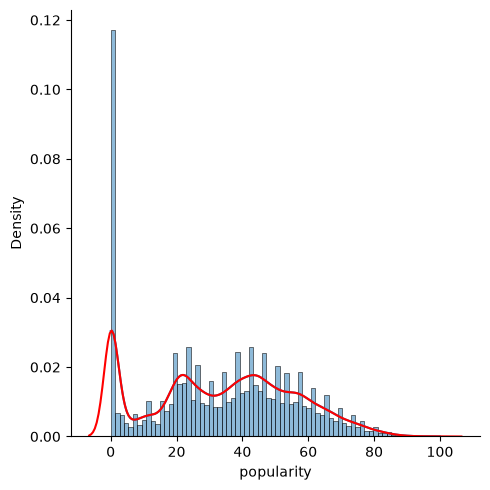

In [102]:
sns.displot(df, x = 'popularity', stat='density', kde=True)
sns.kdeplot(df, x = 'popularity', color = 'red')

<a id="vis-2"></a>  

Visualización 2:

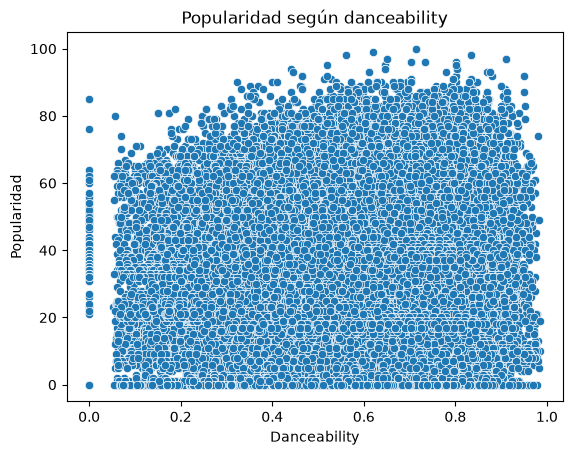

In [103]:
sns.scatterplot(data=df, x="danceability", y="popularity")

plt.title("Popularidad según danceability")
plt.xlabel("Danceability")
plt.ylabel("Popularidad")
plt.show()

<a id="vis-3"></a>  

Visualización 3

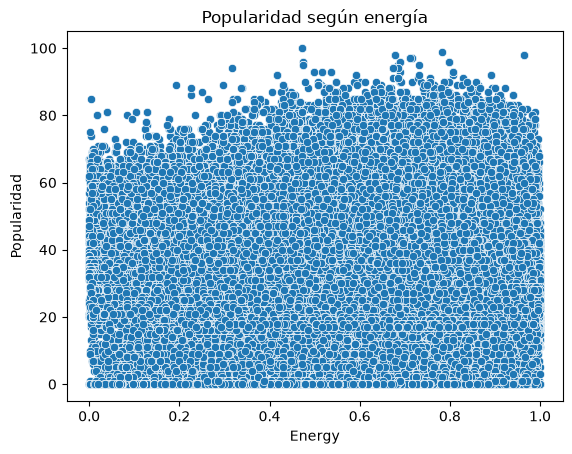

In [104]:
sns.scatterplot(data=df,x="energy",y="popularity")

plt.title("Popularidad según energía")
plt.xlabel("Energy")
plt.ylabel("Popularidad")
plt.show()

<a id="vis-4"></a>  

Visualización 4:

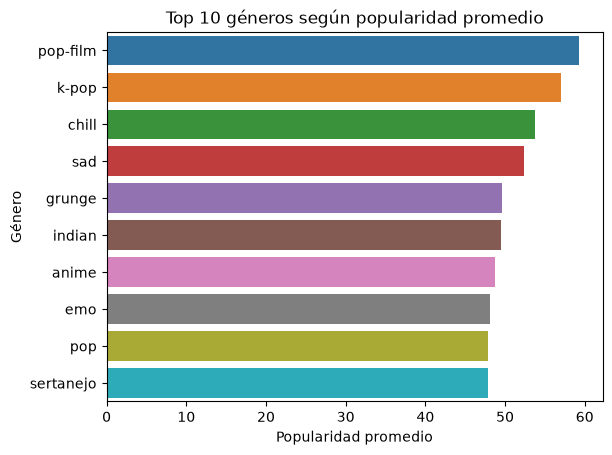

In [105]:
popularidad_genero = (df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(10))

sns.barplot(x=popularidad_genero.values,y=popularidad_genero.index,hue=popularidad_genero.index)

plt.title("Top 10 géneros según popularidad promedio")
plt.xlabel("Popularidad promedio")
plt.ylabel("Género")
plt.show()

<a id="vis-5"></a>
Visualización 5:

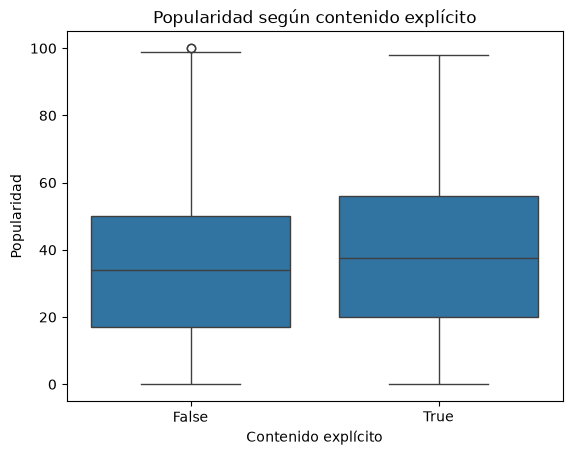

In [106]:
sns.boxplot(data=df, x="explicit", y="popularity")
plt.title("Popularidad según contenido explícito")
plt.xlabel("Contenido explícito")
plt.ylabel("Popularidad")
plt.show()

<a id="vis-6"></a>
Visualización 6:

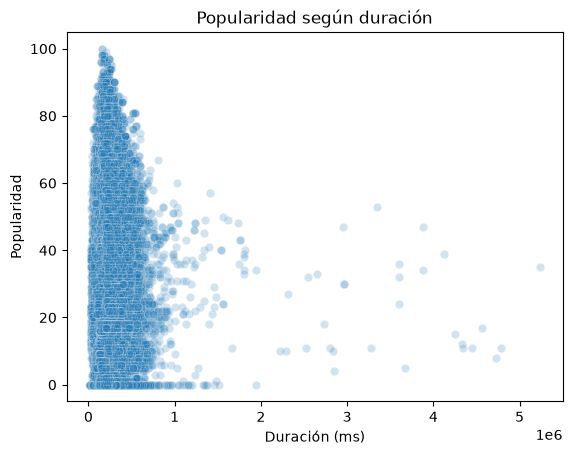

In [107]:
sns.scatterplot(data=df,x="duration_ms",y="popularity",alpha=0.2)

plt.title("Popularidad según duración")
plt.xlabel("Duración (ms)")
plt.ylabel("Popularidad")
plt.show()

---

<a id="section-34"></a>  

## 3.4 Sesgos, ética y privacidad (20%)

Según la rúbrica, para obtener un buen desempeño y obtener el total del 20%, se debe cumplir con lo siguiente:  
* Identificar al menos dos riesgos específicos y pertinentes. Explica su causa o evidencia, los grupos o decisiones afectados, el impacto posible y una mitigación viable para cada riesgo. Incluye una consideración concreta sobre privacidad o uso responsable.  

## Lista de verificación antes de entregar

- [x] El nombre del archivo cumple el formato solicitado.
- [x] Utilicé únicamente el dataset asignado.
- [x] Ejecuté el notebook completo desde el inicio y guardé los resultados.
- [x] Cada transformación relevante está justificada.
- [x] Incluí al menos tres hallazgos con evidencia, interpretación e importancia para el negocio.
- [x] Identifiqué al menos dos riesgos éticos, de sesgo o privacidad y propuse mitigaciones.
- [x] Mi presentación contiene como máximo seis láminas de contenido.
- [x] Todo resultado presentado en el PPTX está respaldado por el notebook.